# 01 · Data Ingestion — SOL-USD
**Data Science Diploma · ENES UNAM León**

We download historical data for Solana (SOL-USD) from Yahoo Finance for the period **2024–2025**.

OHLCV columns:
- **Open** – Opening price
- **High** – Highest price of the day
- **Low** – Lowest price of the day
- **Close** – Closing price *(target variable)*
- **Volume** – Transaction volume

In [ ]:
# ── Install dependencies ──────────────────────────────────────────────
# Run only the first time
# !pip install yfinance pandas numpy matplotlib seaborn ta scikit-learn xgboost

In [19]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import date


# Base paths
RAW_DIR       = os.path.join(os.getcwd(), 'data', 'raw')
PROCESSED_DIR = os.path.join(os.getcwd(), 'data', 'processed')

# File paths
DATA_PATH     = os.path.join(RAW_DIR, 'sol_usd_raw.csv')

# Create folders
os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

print(f'Raw dir      : {RAW_DIR}')
print(f'Processed dir: {PROCESSED_DIR}')

# Global chart settings
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('Libraries loaded successfully')

Raw dir      : /home/dan/Projects/diplomado2025_entregable/data/raw
Processed dir: /home/dan/Projects/diplomado2025_entregable/data/processed
Libraries loaded successfully


## 1.1 Data Download

In [21]:

TICKER     = 'SOL-USD'
START_DATE = '2025-01-01'
END_DATE = date.today().strftime('%Y-%m-%d')
DATA_PATH = os.path.join(os.getcwd(), 'data', 'raw', 'sol_usd_raw.csv')

# Download from Yahoo Finance
df = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True)

# Flatten MultiIndex columns if generated by yfinance (newer versions)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

print(f'Records downloaded : {len(df)}')
print(f'Period             : {df.index.min().date()} → {df.index.max().date()}')
df.tail()

[*********************100%***********************]  1 of 1 completed

Records downloaded : 444
Period             : 2025-01-01 → 2026-03-20


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-03-16,96.223724,97.417717,91.245918,92.258133,6507301442
2026-03-17,94.705971,96.747719,93.322861,96.224236,4239635773
2026-03-18,90.065720,95.539375,88.812065,94.704643,4331839385
2026-03-19,88.917847,91.227554,87.194138,90.064423,3654219084
2026-03-20,89.853569,90.236908,88.241943,88.917252,3090719128


## 1.2 Basic Data Quality Validation

In [22]:
print('=== Shape ===')
print(df.shape)

print('\n=== Data Types ===')
print(df.dtypes)

print('\n=== Null Values ===')
print(df.isnull().sum())

print('\n=== Descriptive Statistics ===')
df.describe().round(2)

=== Shape ===
(444, 5)

=== Data Types ===
Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

=== Null Values ===
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

=== Descriptive Statistics ===


Price,Close,High,Low,Open,Volume
count,444.00,444.00,444.00,444.00,4.440000e+02
mean,158.26,163.36,153.41,158.49,5.382856e+09
std,41.80,43.31,40.35,41.70,3.240619e+09
min,77.75,79.58,68.69,77.75,1.442831e+09
25%,130.40,134.63,126.46,130.81,3.473927e+09
50%,151.84,155.19,147.45,152.05,4.503841e+09
75%,188.50,194.88,183.79,188.57,6.595565e+09
max,261.87,294.33,248.75,261.87,3.317296e+10


In [23]:
# Verify there are no duplicate dates (important in time series)
duplicates = df.index.duplicated().sum()
print(f'Duplicate dates: {duplicates}')

# Verify calendar continuity (business days)
# Crypto operates 7 days — check for gaps greater than 1 day
date_diffs = pd.Series(df.index).diff().dt.days
gaps = date_diffs[date_diffs > 2]
print(f'Gaps > 2 days: {len(gaps)}')
if len(gaps) > 0:
    print(gaps)

Duplicate dates: 0
Gaps > 2 days: 0


## 1.3 Quick Look at the Closing Price

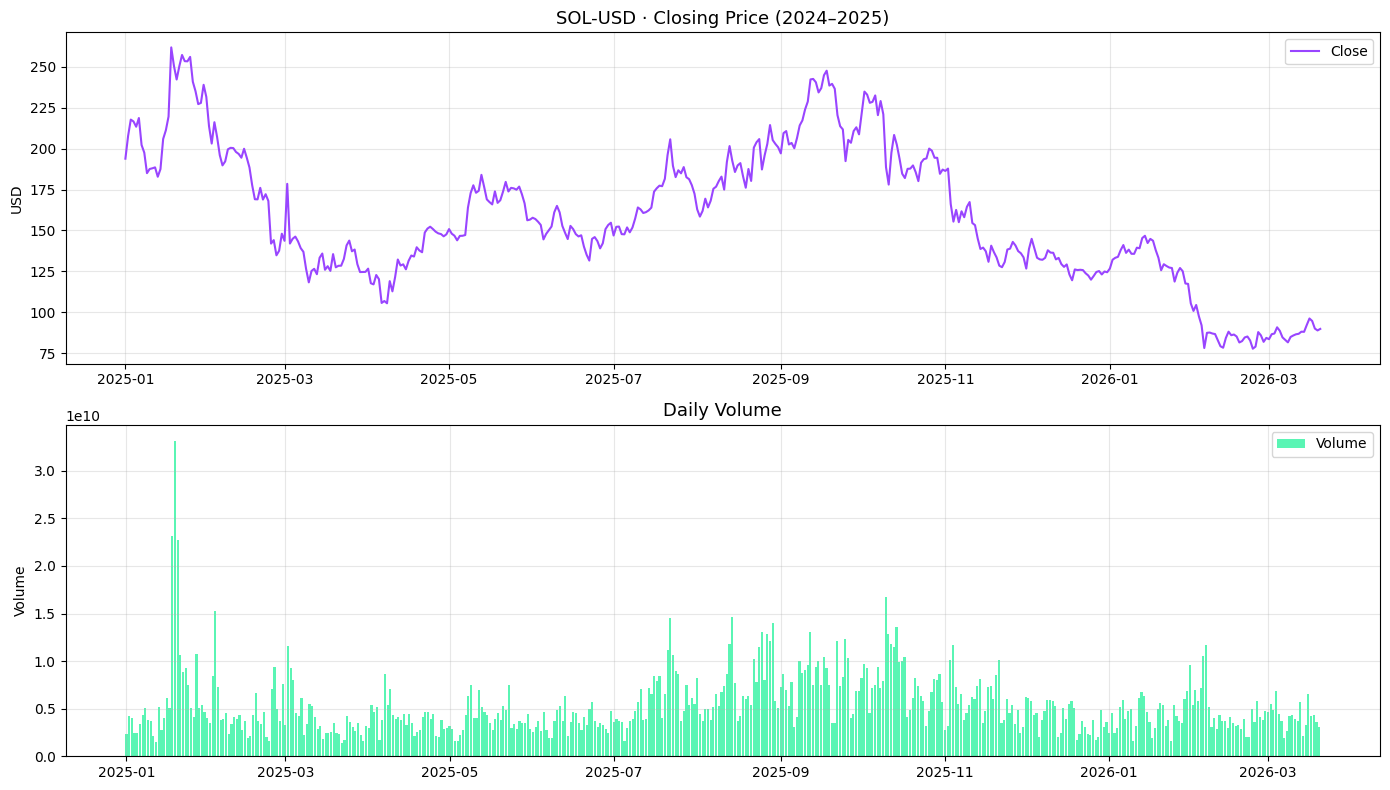

Chart saved


In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Closing price
axes[0].plot(df.index, df['Close'], color='#9945FF', linewidth=1.5, label='Close')
axes[0].set_title('SOL-USD · Closing Price (2024–2025)', fontsize=13)
axes[0].set_ylabel('USD')
axes[0].legend()

# Volume
axes[1].bar(df.index, df['Volume'], color='#14F195', alpha=0.7, label='Volume')
axes[1].set_title('Daily Volume', fontsize=13)
axes[1].set_ylabel('Volume')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(RAW_DIR, '01_price_volume.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved')

## 1.4 Save Raw Data

In [25]:
df.to_csv(DATA_PATH)
print(f'Data saved to: {DATA_PATH}')
print(f'Total records: {len(df)}')

Data saved to: /home/dan/Projects/diplomado2025_entregable/data/raw/sol_usd_raw.csv
Total records: 444


In [11]:
import os
print(os.getcwd())

/home/dan/Projects/diplomado2025_entregable


---
## ✅ Notebook Summary
| Item | Value |
|---|---|
| Ticker | SOL-USD |
| Period | 2024-01-01 → 2025-03-20 |
| Records | *see output above* |
| Null values | 0 |
| Generated file | `data/raw/sol_usd_raw.csv` |

**Next step →** `02_eda.ipynb`